# Introduction to proteomics data analysis with `anndata`

## About anndata 


**What is AnnData and why is it the main data structure of `alphapepttools`?**

[`AnnData`](https://anndata.readthedocs.io/en/stable/) is a Python data for high-dimensional biological data analysis. Originally developed for single-cell genomics, it is increasingly adapted in the scientific ecosystem for the analysis of `omics` data. It forms the central data structure in the [`scverse`](https://scverse.org), an open source software ecosystem for the analysis of omics data. 

AnnData solves a key challenge of modern, high-throughput proteomics: managing thousands of protein measurements alongside complex sample and protein metadata. Unlike pandas DataFrames where mixing numeric and categorical data complicates matrix operations, AnnData keeps measurement and metadata aligned but separate. It can store 

- **Quantitative measurements** (protein abundances, intensities) for thousands of proteins
- **Sample metadata** (experimental conditions, patient demographics, batch information)
- **Protein annotations** (gene names, functional categories, pathway memberships)
- and **Analysis results** (statistical tests, clustering assignments, quality metrics)

at a single place which facilitates handling these large amounts of data. 


**`alphapepttools` is built around `anndata`** and has a suite of useful filtering and processing functions, making your analyses simpler, more robust and - importantly - compatible with Scanpy/Scverse downstream packages

In this tutorial, we explore how AnnData is actually organized to understand how `alphapepttools` enables the search engine-agnostic ingestion of proteomics data into the `scverse`.


### Core components of anndata

Here is a schematic of an AnnData object, which is created by the `AnnData` class of the `anndata` package [1]:

<div align="center">
<img src="../../_static/images/anndata_schema.svg" width="400" height="300">
</div>

For most `alphapepttools` applications, you'll primarily work with three key components:

- **`X`**: The Numeric Expression Matrix <br>
A numpy array where rows represent **samples** and columns represent **features** (e.g., proteins, precursors, genes)

- **`obs`**: Sample Metadata  <br>
A DataFrame where rows are **samples** and columns contain metadata properties (e.g., age, disease state, cohort, batch)

- **`var`**: Feature Metadata <br>
A DataFrame where rows are **features** and columns contain feature properties (e.g., for proteins: Gene names, GO terms, functional annotations)

This structure ensures that when you filter samples or features, all associated metadata automatically stays synchronized, preventing common annotation misalignment issues in analysis workflows.

[1] [AnnData Documentation](https://anndata.readthedocs.io/en/stable/)

## About MuData & MuLink

`MuData` is a class of data objects from the `mudata` package, which can hold multiple `AnnData` instances in one object for convenient storage and access [2]. Dealing with the multi-layered nature of proteomics data, where measurements can be thought of as hierarchical assemblies of precursors, peptides, proteins and genes, inspired the development of `MuLink`, an extension of `MuData` that allows modeling of feature relationships between different `AnnDatas` inside a `MuData` instance [3]. This is extremely helpful to query precursor, peptide, protein and gene level datasets together, for example in differential expression experiments, where we might want to know which genes, but also which protein isoforms (protein level) are regulated.

This notebook contains an introduction for working with proteomics data in `MuLink` objects.

[2] [MuData Documentation](https://mudata.readthedocs.io/stable/)

[3] [MuLink Documentation](github.com/lucas-diedrich/mulink)
 

### Basic AnnData syntax

We will now explore how users can create and interact with anndata and finally show how `alphapepttools` enables the search-engine agnostic creation of `anndata` objects from the raw outputs.


Import the relevant modules

In [ ]:
%load_ext autoreload
%autoreload 2

import anndata as ad
import numpy as np
import pandas as pd
import alphapepttools as apt
import tempfile
import matplotlib.pyplot as plt

/Users/lucas-diedrich/mamba/envs/alphatools/lib/python3.13/site-packages/alphaquant/quant_reader/longformat_reader.py:12: UserWarning: Dependency 'dask' not installed. If you want to use its functionality, install it with: `pip install "alphaquant[dask]"` . Falling back to non-dask based processing.
  warnings.warn(
/Users/lucas-diedrich/mamba/envs/alphatools/lib/python3.13/site-packages/alphaquant/ptm/ptmsite_mapping.py:30: UserWarning: Dependency 'dask' not installed. If you want to use its functionality, install it with: `pip install "alphaquant[dask]"` . ImportError will be raised if the data requires out-of-memory processing.
  warnings.warn(


We'll start by manually creating a small synthetic anndata object. Under the hood, `anndata` uses very familiar data structures such as `numpy` arrays and `pandas` Dataframes.

In [ ]:
numerical_data = np.array([[1, 0, 0], [0, 2, 3]])

sample_metadata = pd.DataFrame(
    {
        "obs_names": ["cell1", "cell2"],
        "age": [28, 29],
    }
).set_index("obs_names")

feature_metadata = pd.DataFrame({"var_names": ["gene1", "gene2", "gene3"]}).set_index("var_names")

# Generate AnnData object
adata = ad.AnnData(
    X=numerical_data,
    obs=sample_metadata,
    var=feature_metadata,
)

# We can get a dataframe back
df = adata.to_df()
display(df)

# And also look at the sample and feature metadata
display(adata.obs)
display(adata.var)

var_names,gene1,gene2,gene3
obs_names,,,
cell1,1,0,0
cell2,0,2,3


,age
obs_names,
cell1,28
cell2,29


""
var_names
gene1
gene2
gene3


### Conversion to other data structures
To *get out* of AnnData and back to the more familiar world of dataframes, just run the builtin `.to_df()` function

In [ ]:
df = adata.to_df()
display(df)

# Get your sample metadata added as columns
df = df.join(adata.obs)
display(df)

var_names,gene1,gene2,gene3
obs_names,,,
cell1,1,0,0
cell2,0,2,3


,gene1,gene2,gene3,age
obs_names,,,,
cell1,1,0,0,28
cell2,0,2,3,29


## How to load search engine data into AnnData with `alphapepttools`?

The functionality relies on the `alphabase` backbone of PSM and PG readers, which allows for loading and parsing of common search engine output formats. In this notebook we will look at reading data for three common search engines: DIANN, AlphaDIA and Spectronaut. Search engines output data in two main ways: Either as a *long table*, where rows are individual precursors in their respective samples:

### PSM tables

Peptide spectrum match (PSM) tables are the primary output of proteomics search engines and typically returned in a *long format*. In a PSM table, each row typically represents a single peptide-spectrum-match, i.e. a peptide sequence that the proteomics search engine identified to be compatible with an observed mass spectrum in a given sample. PSM tables contain information about both 1) the peptide sequence, 2) the spectrum, as well as 3) the score assigned to the PSM by the search engine.

An example for a PSM table could be something like this


| Precursor | Run | Stripped.Sequence | ... |
|-----------|-----|-------------------|-----|
| PEPTIDEK1 | file_1.raw | PEPTIDEK | ... |
| PEPTIDERK2 | file_1.raw | PEPTIDERK | ... |
| PEPTIDR2 | file_1.raw | PEPTIDR | ... |
| PEPTIDEK1 | file_2.raw | PEPTIDEK | ... |
| PEPTIDERK2 | file_2.raw | PEPTIDERK | ... |
| PEPTIDR2 | file_2.raw | PEPTIDR | ... |
| PEPTIDEK1 | file_3.raw | PEPTIDEK | ... |
| PEPTIDERK2 | file_3.raw | PEPTIDERK | ... |
| PEPTIDR2 | file_3.raw | PEPTIDR | ... |

### Protein group tables

Protein group tables are the primary output for protein-level quantification in proteomics workflows. After search engines identify peptide spectrum matches, they aggregate peptide-level evidence to infer protein-level abundances. These protein group tables represent a structured matrix in the *wide format* that maps protein groups (features) to samples (observations), with estimated intensity values as entries.

| Protein | file_1.raw | file_2.raw | file_3.raw | ... |
|---------|------------|------------|------------|-----|
| PROT1 | 1000 | 1200 | 1100 | ... |
| PROT2 | 2000 | 2200 | 2100 | ... |
| PROT3 | 1500 | 1600 | 1550 | ... |
| ... | ... | ... | ... | ... |


Typically, downstream analysis tasks are performed on a sample level. Therefore, we are usually interested in a transposed version of the wide format, where rows correspond to samples and columns to features. **alphapepttools allows users to easily generate compliant `anndata` objects from raw search engine outputs with its I/O functionalities**.

### Getting the example data

Small versions of larger real-world datasets are stored in a public repository.  Users can access them via the utility function `alphapepttools.data.get_data`. 

We can inspect the available datasets with: 

In [ ]:
apt.data.available_data()

,name,url,search_engine,data_type,citation,description
0,bader2020_pg_alphadia,https://datashare.biochem.mpg.de/s/yLpjkoQzMHpdDsB,alphadia,study_pg,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Study on Cerebral Spinal Fluid of Alzheimer patients by Bader et al.
1,bader2020_pg_diann,https://datashare.biochem.mpg.de/s/3oZsya2L5bGnmtQ,DiaNN,study_pg,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Study on Cerebral Spinal Fluid of Alzheimer patients by Bader et al.
2,spectronaut_pg,https://datashare.biochem.mpg.de/s/Ai9TiBTeaPHK5by,spectronaut,pg,None,An example spectronaut report
3,bader2020_psm_alphadia,https://datashare.biochem.mpg.de/s/awYyxod4ksz86kk,alphadia,study_psm,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Study on Cerebral Spinal Fluid of Alzheimer patients by Bader et al.
4,bader2020_psm_diann,https://datashare.biochem.mpg.de/s/c4Z5Yg6srKQyDym,DiaNN,study_psm,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Study on Cerebral Spinal Fluid of Alzheimer patients by Bader et al.
5,spectronaut_psm,https://datashare.biochem.mpg.de/s/GtfJL49Rf9w78EE,spectronaut,study_psm,None,An example spectronaut report
6,uniprotkb_proteome_UP000005640_AND_revi_2025_07_22,https://datashare.biochem.mpg.de/s/ik882JwmeDXyoNN,none,proteome,None,"UniprotKB proteome for Homo sapiens, reviewed entries, release 2025_07_22"
7,bader2020_full_diann,https://datashare.biochem.mpg.de/s/zNtxEQJTdqQYLd4,DiaNN,psm,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Full DiaNN report.parquet for the Bader et al. Alzheimer CSF study
8,bader2020_full_alphadia,https://datashare.biochem.mpg.de/s/F2BEq9j7ptEstNm,alphadia,psm,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease. Mol Syst Biol. 2020 Jun;16(6):e9356. doi: 10.15252/msb.20199356. PMID: 32485097; PMCID: PMC7266499.",Full AlphaDIA precursors.tsv for the Bader et al. Alzheimer CSF study
9,bader2020_metadata,https://datashare.biochem.mpg.de/s/iSgdPnHgczbcktF,none,metadata,"Bader JM, Geyer PE, Müller JB, Strauss MT, Koch M, Leypoldt F, Koertvelyessy P, Bittner D, Schipke CG, Incesoy EI, Peters O, Deigendesch N, Simons M, Jensen MK, Zetterberg H, Mann M. Proteome profiling in cer

### Protein Group Tables

Let's first take a look a the protein group tables.

When you inspect the raw files you will notice that [protein group table outputs vary significantly between search engines](https://alphabase.readthedocs.io/en/latest/tutorials/tutorial_pg_reader.html) with respect to the features and quantities they contain. `alphapepttools` provides a single function `alphapepttools.io.read_pg_table()` to read any of the widely used search engine reports into the streamlined `anndata` format.

You only need to specify the path to the raw output and the type of search engine that generated the output.


### alphadia

In [ ]:
output_dir = "./datasets/data_for_00_data_sources"
data_path = apt.data.get_data("bader2020_pg_alphadia", output_dir=output_dir if output_dir else tempfile.mkdtemp())

./datasets/data_for_00_data_sources/bader2020_alphadia_pg already exists (0.27982044219970703 MB)


In [ ]:
alphadia_pg_anndata = apt.io.read_pg_table(
    path=data_path / "pg.matrix_top100.tsv",
    search_engine="alphadia",
)

alphadia_pg_anndata

AnnData object with n_obs × n_vars = 61 × 100
    layers: None (.X)

In [ ]:
# Inspect the data
display(alphadia_pg_anndata.to_df().iloc[:5, :5])
display(alphadia_pg_anndata.obs.head())
display(alphadia_pg_anndata.var.head())

uniprot_ids,A0A024R6N5;A0A0G2JRN3,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleE01,0.000000e+00,2.098375e+07,1.603786e+09,1.234308e+09,9.981811e+07
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB05,5.248854e+07,1.558676e+07,1.264443e+09,1.017132e+09,1.438419e+08
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB11,3.063311e+08,7.633061e+06,9.859006e+08,6.482135e+08,5.423701e+07
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA12,1.558016e+08,1.442227e+07,3.558411e+08,1.124133e+09,8.751671e+07
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB03,2.585067e+08,4.627953e+07,1.224894e+09,8.738715e+08,8.460091e+07


""
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleE01
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB05
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB11
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA12
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB03


""
uniprot_ids
A0A024R6N5;A0A0G2JRN3
A0A075B6H7
A0A075B6H9
A0A075B6I0
A0A075B6I1


### DIANN

Similarly you can proceed with alternative search engine outputs like DIANN's protein group table. Note that DIANN outputs additional feature-level metadata compared to alphadia that is stored in the `anndata.AnnData.var` attribute.

In [ ]:
output_dir = "./datasets/data_for_00_data_sources"
data_path = apt.data.get_data("bader2020_pg_diann", output_dir=output_dir if output_dir else tempfile.mkdtemp())

./datasets/data_for_00_data_sources/bader2020_diann_pg already exists (0.08965206146240234 MB)


In [ ]:
# Using the pg reader
diann_pg_anndata = apt.io.read_pg_table(
    path=data_path / "pg.matrix_top100.tsv",
    search_engine="diann",
)

# Inspect the data
display(diann_pg_anndata.to_df().iloc[:5, :5])
display(diann_pg_anndata.obs.head())
display(diann_pg_anndata.var.head())

proteins,LV469_HUMAN,LV861_HUMAN,LV460_HUMAN,LV548_HUMAN,LV746_HUMAN
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleE01.raw,77220500.0,103374000.0,10956700.0,NaN,125708000.0
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB05.raw,39566800.0,71580200.0,12655900.0,NaN,55909900.0
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB11.raw,27392100.0,42695000.0,4543130.0,NaN,89816500.0
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA12.raw,12829700.0,55057200.0,7905720.0,202590.0,53537600.0
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB03.raw,33979400.0,66161200.0,4035670.0,NaN,112146000.0


""
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleE01.raw
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB05.raw
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB11.raw
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA12.raw
/fs/gpfs41/lv12/fileset02/pool/pool-mann-projects/alphatools/alzheimers_dataset/RAWDATA/20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB03.raw


,uniprot_ids,genes,description,peptide_count,proteotypic_peptide_count
proteins,,,,,
LV469_HUMAN,A0A075B6H9,IGLV4-69,NaN,2,2
LV861_HUMAN,A0A075B6I0,IGLV8-61,NaN,3,3
LV460_HUMAN,A0A075B6I1,IGLV4-60,NaN,2,2
LV548_HUMAN,A0A075B6I7,IGLV5-48,NaN,1,1
LV746_HUMAN,A0A075B6I9,IGLV7-46,NaN,3,1


### Spectronaut

In [ ]:
# data_path = at.data.get_data("spectronaut_pg")

In [ ]:
# sn_pg_anndata = at.io.read_pg_table(
#     path=data_path / "spectronaut_protein_table.tsv",
#     search_engine="spectronaut",


# # Inspect the data
# display(sn_pg_anndata.to_df().iloc[:5, :5])
# display(sn_pg_anndata.obs.head())
# display(sn_pg_anndata.var.head())

## Protein data from precursor spectrum match tables

You can similarly extract the protein intensity information from PSM tables with the `alphapepttools.io.read_psm_table` function. Note that the information from the pg tables and psm tables might differ. 

When might you use PSM tables instead of PG tables? 

- You might choose PSM tables when you need custom protein quantification strategies that differ from the search engine's default approach, 
- when you want to perform quality control at the precursor level to identify problematic peptides, 
- when you're integrating protein data with peptide-level analyses, 
- or when protein group tables aren't available from your search engine.

We explore again examples for PSM reports from different search engines.

### AlphaDIA

In [ ]:
output_dir = "./datasets/data_for_00_data_sources"
data_path = apt.data.get_data("bader2020_psm_alphadia", output_dir=output_dir if output_dir else tempfile.mkdtemp())

./datasets/data_for_00_data_sources/alphadia already exists (8.177705764770508 MB)


In [ ]:
ad_psm_andata = apt.io.read_psm_table(
    file_paths=data_path / "top20_precursors.tsv",
    search_engine="alphadia",
)
ad_psm_andata

AnnData object with n_obs × n_vars = 60 × 19
    layers: None (.X)

In [ ]:
# Inspect the data
display(ad_psm_andata.to_df().iloc[:5, :5])
display(ad_psm_andata.obs.head())
display(ad_psm_andata.var.head())

proteins,P01009;A0A024R6N5,P01011;A0A087WY93;G3V3A0;G3V595,P01024;A0A8Q3SI05;A0A8Q3SI34;A0A8Q3WM02,P02675;D6REL8,P02787
raw_name,,,,,
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,NaN,NaN,5.122159e+09,NaN,1.383408e+11
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,3.942457e+09,1.895097e+09,7.004725e+09,5.359053e+09,1.166750e+11
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,3.670290e+09,1.466623e+09,1.070513e+10,4.963886e+09,1.096607e+11
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,5.022584e+09,1.653896e+09,6.425221e+09,5.095784e+09,1.073282e+11
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,3.314550e+09,1.044103e+09,5.690721e+09,4.237927e+09,8.503823e+10


""
raw_name
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05


""
proteins
P01009;A0A024R6N5
P01011;A0A087WY93;G3V3A0;G3V595
P01024;A0A8Q3SI05;A0A8Q3SI34;A0A8Q3WM02
P02675;D6REL8
P02787


### DIANN

In [ ]:
output_dir = "./datasets/data_for_00_data_sources"
data_path = apt.data.get_data("bader2020_psm_diann", output_dir=output_dir if output_dir else tempfile.mkdtemp())

./datasets/data_for_00_data_sources/diann already exists (61.70798587799072 MB)


In [ ]:
diann_pg_andata = apt.io.read_psm_table(
    file_paths=data_path / "top20_report.parquet",
    search_engine="diann",
)

# Inspect the data
display(diann_pg_andata.to_df().iloc[:5, :5])
display(diann_pg_andata.obs.head())
display(diann_pg_andata.var.head())

proteins,P01011,P02649,P02671,P02765,P02768
raw_name,,,,,
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,9.798148e+08,6.036072e+09,129011936.0,1.455730e+09,1.929707e+10
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,1.396344e+09,7.632371e+09,204724768.0,1.515461e+09,2.287499e+10
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,1.025414e+09,4.464353e+09,204250576.0,9.584196e+08,1.264076e+10
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,1.272798e+09,6.688002e+09,192892832.0,1.185967e+09,1.557733e+10
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,8.905130e+08,4.973349e+09,206050384.0,1.481705e+09,1.579670e+10


""
raw_name
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05


""
proteins
P01011
P02649
P02671
P02765
P02768


### Spectronaut

In [ ]:
# data_path = at.data.get_data("spectronaut_psm")

In [ ]:
# sn_pg_andata = at.io.read_psm_table(
#     file_paths=data_path / "example_dataset_mouse_sn_top20peptides.tsv",
#     search_engine="spectronaut",
#     intensity_column = "F.PeakArea",
#     feature_id_column = "FG.Id"
# )

# # Inspect the data
# display(sn_pg_andata.to_df().iloc[:5, :5])
# display(sn_pg_andata.obs.head())
# display(sn_pg_andata.var.head())

## In Summary, we learned...

- How AnnData can help us keep our data and metadata aligned
- How to generate AnnData objects from our input dataframes
- How to get dataframes back from AnnData objects
- How to load protein tables using `alphapepttools` readers
- How to load and pivot PSM tables using `alphapepttools` readers

From here on, proteomics data can be used for all further downstream analyses. Continue with the basic workflow notebook to learn how to merge your metadata into AnnData objects and perform filtering and exploratory data analysis!

## Read PSM-tables into a `MuLink` instance of linked AnnData objects

The `MuData` format was designed as a data structure to hold multiple `AnnData` instances, conceptually similar to a dict of `AnnData`s. `MuLink` (https://github.com/lucas-diedrich/mulink) is an extension of the `MuData`format that introduces hierarchical linkage between features of different `AnnDatas`. In the proteomics context, this could mean linking protein, gene and precursor `AnnData` instances in a way that reflects the underlying proteomics measurement: precursors aggregate to protein isoforms, multiple protein isoforms can aggregate into a gene. `alphapepttools` contains a simple wrapper class to read PSM-tables from common search engines into `MuLink` instances, which makes it possible to query them together: if a researcher wants to isolate all precursors belonging to a certain isoform in their dataset, they can simply query the `MuLink` instance and get filtered `AnnData`s for both proteins and precursors. 

In the following cells we provide a brief demonstration of the wrapper function.

In [ ]:
# Read precursor, protein and gene-level AnnDatas into a MuLink instance
adata_precursor = apt.io.read_psm_table(
    file_paths=data_path / "top20_report.parquet",
    search_engine="diann",
    level="precursors",
    var_columns=["proteins", "genes"],  # include protein and gene annotation for precursor-level data
)

adata_protein = apt.io.read_psm_table(
    file_paths=data_path / "top20_report.parquet",
    search_engine="diann",
    level="proteins",
    var_columns="genes",  # include gene annotation for protein-level data
)

adata_gene = apt.io.read_psm_table(
    file_paths=data_path / "top20_report.parquet",
    search_engine="diann",
    level="genes",
)

mlink = apt.io.mulink_from_anndatas(
    anndatas={
        "precursors": adata_precursor,
        "proteins": adata_protein,
        "genes": adata_gene,
    }
)

100%|██████████| 2/2 [00:00<00:00, 640.99it/s]


The linked feature levels can be visualized as a graph, connecting precursors, proteins and genes:

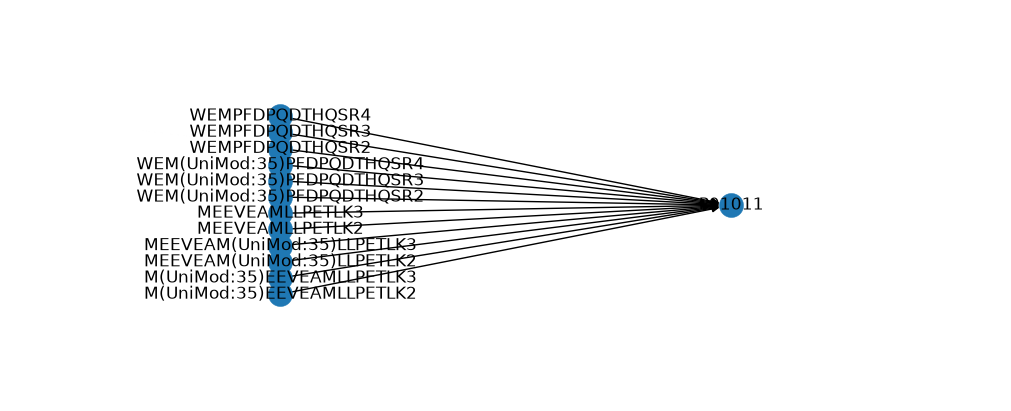

In [ ]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(10, 4))
ax = axm.next()
(mlink.link.query.ancestors("P01011").link.pl.graph(with_labels=True, ax=ax))
plt.margins(0.5)
plt.show()

### Querying `MuLink` instances

A common proteomics question could be "which isoforms of my gene of interest did I measure?", as well as "Which specific precursors of my protein of interest did I actually measure?". `MuLink`'s querying function makes use of the underlying graph represention of the hierarchical data to slice all modalities efficiently and allow cross-modality queries:

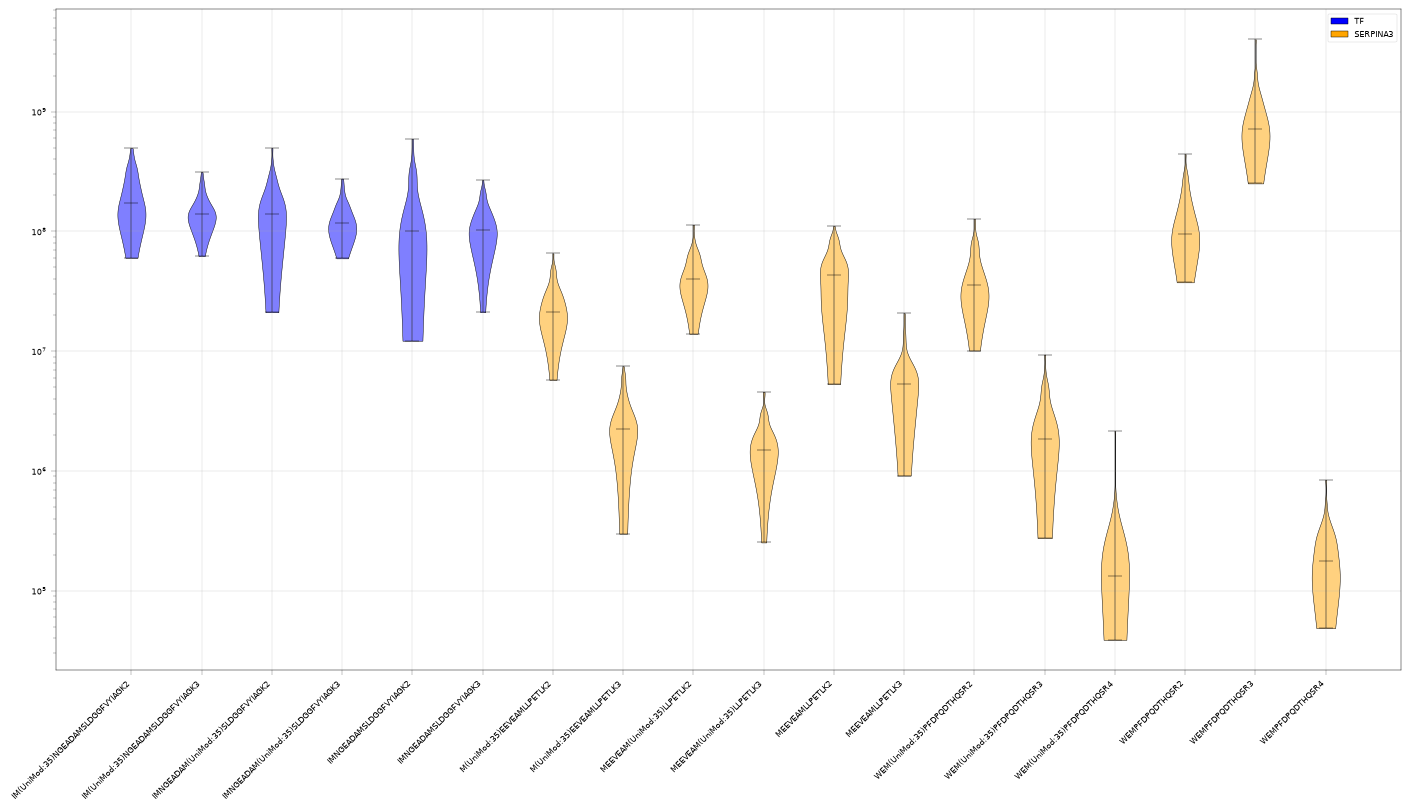

In [ ]:
# Question: which proteins and precursors are associated with the "TF" and the "SERPINA3" gene?

# get filtered AnnDatas:
tf_genes = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["genes"]
tf_proteins = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["proteins"]
tf_precursors = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["precursors"]

# Assign a color based on the underlying gene to each precursor
gene_colors = {"TF": "blue", "SERPINA3": "orange"}
precursor_colors = tf_precursors.var["genes"].map(gene_colors).to_dict()

# Display precursors as a barplot
fig, axm = apt.pl.create_figure(1, 1, figsize=(14, 8))
ax = axm.next()

# log-transform y axis
ax.set_yscale("log")

# TF precursors
apt.pl.violinplot(
    ax=ax,
    data=tf_precursors.to_df(),
    direct_columns=tf_precursors.var_names,
    color_dict=precursor_colors,
)

# Add legend
apt.pl.add_legend_to_axes(
    ax=ax,
    levels=gene_colors,
)

# rotate x labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()